## Vehicle Detection Pipeline


## Architecture Overview
```
Video Frame
  │
  ▼
Phase 1 ──► compute_frame_similarity(frame_a, frame_b)  ← Levenshtein similarity (UNCHANGED)
  │            if ratio <= threshold → skip frame (frames too similar, no new vehicle)
  │            if ratio >  threshold → process frame (scene changed enough)
  ▼
Phase 2 ──► vehicle_type_detection()    → YOLO model 1 (MODEL1_PATH)
  │              if confidence < 0.80   → skip
  │              else → crop bbox
  ▼
         ──► vehicle_identity_detection() → YOLO model 2 (MODEL2_PATH)
  │              if confidence < 0.80   → skip
  │              else → crop bbox
  ▼
         ──► extract_plate_text()
                  tricycle  → r'\d{4}'
                  other     → r'[A-Z]{3}\d{3,4}'
  │
  ▼
OCR Deduplication (Levenshtein on identity strings within bbox tracks)
  │
  ▼
detections.csv  +  metrics.csv
  │
  ▼
report.csv  (threshold sweep 0.00 → 1.00, step 0.01 — NO re-detection needed)
```

In [ ]:
 !pip install python-Levenshtein ultralytics easyocr

  Using cached levenshtein-0.27.3-cp312-cp312-win_amd64.whl.metadata (3.7 kB)
Using cached levenshtein-0.27.3-cp312-cp312-win_amd64.whl (94 kB)


## Imports

In [1]:
# %% Cell 2 — Imports
import cv2
import numpy as np
import csv
import re
import time
import tqdm
from collections import defaultdict
from typing import List, Optional, Tuple, Dict

import pandas as pd
from collections import Counter
import warnings

import Levenshtein as lv
from ultralytics import YOLO
import easyocr

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

In [ ]:
# — Configuration & Singletons
# ─── Paths (CONFIGURE THESE YOURSELF) ─────────────────────────────────────
MODEL1_PATH  = 'model/model1 - v2.pt'   # YOLO: vehicle type detector
MODEL2_PATH  = 'model/model2 - v1.pt'   # YOLO: plate/identity detector
VIDEO_PATH   = 'video/traffic_dataset.mp4'
VIDEO_TYPE   = 'traffic'

# ─── Thresholds ───────────────────────────────────────────────────────────
CONF_THRESH     = 0.90   # YOLO detection confidence
IOU_THRESH      = 0.30   # IoU to match same vehicle across frames
OCR_LV_DIST     = 2      # max edit-distance to merge OCR readings in a track
SWEEP_LV_DIST   = 2      # max edit-distance for dedup in threshold sweep
OCR_CONF_THRESH = 0.70   # minimum OCR reading confidence accepted

# ─── Output files ─────────────────────────────────────────────────────────
DETECTIONS_CSV = 'detections.csv'
METRICS_CSV    = 'metrics.csv'
REPORT_CSV     = 'report.csv'

# ─── Lazy singletons ──────────────────────────────────────────────────────
_model1     = None
_model2     = None
_ocr_reader = None

# CLAHE created once at module level; avoids re-instantiation on every
#       prepare_plate_image_for_ocr() call (previously O(N) object creations).
_clahe      = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

def get_model1():
    global _model1
    if _model1 is None:
        _model1 = YOLO(MODEL1_PATH)
    return _model1

def get_model2():
    global _model2
    if _model2 is None:
        _model2 = YOLO(MODEL2_PATH)
    return _model2

def get_ocr():
    """Returns the EasyOCR reader singleton."""
    global _ocr_reader
    if _ocr_reader is None:
        _ocr_reader = easyocr.Reader(['en'], gpu=True)
        print('EasyOCR reader initialised (GPU)')
    return _ocr_reader


## Preprocess all the frames

- Performs a one-time preprocessing of all video frames  
- Opens the video using OpenCV and reads frames sequentially  

- Resizes each frame using a scaling factor (default: 5%)  
  - Reduces memory usage  
  - Speeds up processing  

- Converts each resized frame to grayscale  
  - Removes color information  
  - Preserves structural features  

- Converts each frame into raw bytes  
  - Enables fast similarity comparison (e.g., Levenshtein distance)  

- Stores all processed frames in memory  
- Displays a progress bar during extraction  
- Releases the video resource after processing  

- Returns a list of byte-encoded frames for reuse without reloading the video  

In [ ]:
def precompute_video_frames(video_path: str, scale: float = 0.05):
    print("Pre-processing video frames into memory (One-time pass)...")
    cap = cv2.VideoCapture(video_path)
    frames_bytes = []
    
   
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) # Total frame count used for progress tracking (may be approximate)
    
    with tqdm.tqdm(total=total_frames, desc="Extracting frames") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret: 
                break
                
            h, w = frame.shape[:2]
            new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale)) # Ensure dimensions never become zero after scaling
            
            
            small = cv2.resize(frame, (new_w, new_h))
            gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
            frames_bytes.append(gray.tobytes()) # Convert frame to raw bytes for fast similarity comparison (e.g., Levenshtein)
            
            pbar.update(1)
            
    cap.release()
    return frames_bytes

In [4]:
# 1. Pre-load the video bytes (Will take a minute, but only happens once!)
cached_frames_bytes = precompute_video_frames(VIDEO_PATH, scale=0.05)

Pre-processing video frames into memory (One-time pass)...


Extracting frames: 100%|██████████| 26006/26006 [02:59<00:00, 145.24it/s]


# Phase 1 — Frame Similarity

- Computes similarity between two video frames using a byte-level comparison method  
- Resizes both frames using a scaling factor (default: 20%)  
  - Reduces computation cost  
  - Ensures consistent dimensions for comparison  

- Converts resized frames to grayscale  
  - Removes color information  
  - Focuses on structural content  

- Transforms both frames into raw byte format  
  - Enables string-based similarity computation  

- Uses Levenshtein ratio to measure similarity between frames  
  - Returns a value between 0 and 1  
  - Higher values indicate more similar frames  

- Designed for fast, approximate frame comparison in video analysis workflows  

In [ ]:
def compute_frame_similarity(frame_a: np.ndarray, frame_b: np.ndarray, scale: float = 0.2) -> float:
    
    h, w = frame_a.shape[:2]
    new_w, new_h = int(w * scale), int(h * scale)
    a_small = cv2.resize(frame_a, (new_w, new_h))
    b_small = cv2.resize(frame_b, (new_w, new_h))
    gray_a = cv2.cvtColor(a_small, cv2.COLOR_BGR2GRAY)
    gray_b = cv2.cvtColor(b_small, cv2.COLOR_BGR2GRAY)
    return lv.ratio(gray_a.tobytes(), gray_b.tobytes())

# Phase 2 — Detection and OCR Pipeline

- Processes vehicle frames to detect vehicles, extract identity regions, and recognize plate text  

In [ ]:
# Plate Image Preprocessing
def prepare_plate_image_for_ocr(crop: np.ndarray) -> np.ndarray:
    if crop is None or crop.size == 0:
        return crop

    h, w = crop.shape[:2]

    # 1 — Upscale 
    # Ensure minimum height for OCR while avoiding division by zero
    target_h = max(100, h)
    scale_f  = target_h / max(h, 1)
    new_w    = max(int(w * scale_f), 1)
    crop = cv2.resize(crop, (new_w, target_h), interpolation=cv2.INTER_CUBIC)

    # 2 — Grayscale
    
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    # 3 — CLAHE singleton
    gray = _clahe.apply(gray)

    # 4 — Gaussian blur
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # 5 — Unsharp mask
    blurred = cv2.GaussianBlur(gray, (0, 0), sigmaX=3)
    gray    = cv2.addWeighted(gray, 1.5, blurred, -0.5, 0)
    gray    = np.clip(gray, 0, 255).astype(np.uint8)

    # 6 — Restore BGR
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)


In [ ]:
#Vehicle Detection (returns ALL detections)
def vehicle_type_detection(
    frame: np.ndarray,
    conf: float = CONF_THRESH
) -> List[Tuple[str, Tuple[int,int,int,int], float]]:
    model = get_model1()
    results = model(frame, verbose=False)

    detections: List[Tuple[str, Tuple[int,int,int,int], float]] = []
    for r in results:
        for box in r.boxes:
            c = float(box.conf[0])
            if c >= conf:
                cls_name = model.names[int(box.cls[0])]
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                detections.append((cls_name, (x1, y1, x2 - x1, y2 - y1), c))

    detections.sort(key=lambda d: d[2], reverse=True)
    return detections


def vehicle_identity_detection(
    cropped: np.ndarray,
    conf: float = CONF_THRESH
) -> Optional[np.ndarray]:
    """Detect plate/identity region inside cropped vehicle via MODEL2.
    Returns best crop or None. (Logic unchanged; safety guards added.)"""
    if cropped is None or cropped.size == 0:
        return None

    model = get_model2()
    results = model(cropped, verbose=False)

    best_crop = None
    best_conf  = -1.0

    for r in results:
        for box in r.boxes:
            c = float(box.conf[0])
            if c >= conf and c > best_conf:
                best_conf = c
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                x1 = max(0, x1); y1 = max(0, y1)
                x2 = min(cropped.shape[1], x2)
                y2 = min(cropped.shape[0], y2)
                if y2 > y1 and x2 > x1:
                    best_crop = cropped[y1:y2, x1:x2]

    return best_crop

In [ ]:
_PATTERN_TRICYCLE  = re.compile(r'\d{4}')
_PATTERN_PLATE_NEW = re.compile(r'[A-Z]{3}\d{3,4}')
_PATTERN_PLATE_OLD = re.compile(r'[A-Z]{2}\d{4,5}')  


def match_plate_pattern(raw: str, vehicle_type: str) -> Optional[str]:
    """Try all applicable plate patterns; return first match."""
    if vehicle_type.lower() == 'tricycle':
        m = _PATTERN_TRICYCLE.search(raw)
        return m.group(0) if m else None
    for pat in (_PATTERN_PLATE_NEW, _PATTERN_PLATE_OLD):
        m = pat.search(raw)
        if m:
            return m.group(0)
    return None


def extract_plate_text(
    identity_crop: np.ndarray,
    vehicle_type: str
) -> Optional[str]:
    if identity_crop is None or identity_crop.size == 0:
        return None

    processed = prepare_plate_image_for_ocr(identity_crop)
    reader = get_ocr()
    raw = ''

    try:
        #detail=1 exposes confidence (original used detail=0)
        results = reader.readtext(processed, detail=1, paragraph=False)
        texts   = [r[1] for r in results if r[2] >= OCR_CONF_THRESH]
        raw     = ''.join(texts).replace(' ', '').upper()
    except Exception as e:
        print(f'  [OCR warning] {e}')
        raw = ''

    return match_plate_pattern(raw, vehicle_type)

# Phase 3 — OCR Deduplication via IoU Tracking and Levenshtein Clustering

- Tracks detected vehicles across video frames to avoid duplicate counting  
- Uses bounding-box overlap to determine whether detections belong to the same vehicle  
- Collects OCR readings from each tracked vehicle across multiple frames  
- Groups similar OCR readings using Levenshtein distance  
- Selects the most frequent OCR reading as the vehicle’s canonical identity  

### Problem

OCR results are noisy. The same physical vehicle can produce slightly different plate readings across consecutive frames.

Example:

```text
3023 → 3022 → 3033

In [ ]:
#IoU Tracker + Fixed Canonical Identity
def _iou(boxA: Tuple, boxB: Tuple) -> float:
    """Compute Intersection over Union for two (x, y, w, h) bounding boxes."""
    ax1, ay1 = boxA[0], boxA[1]
    ax2, ay2 = ax1 + boxA[2], ay1 + boxA[3]
    bx1, by1 = boxB[0], boxB[1]
    bx2, by2 = bx1 + boxB[2], by1 + boxB[3]
    ix1 = max(ax1, bx1); iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2); iy2 = min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)                           # Calculate intersection area between the two bounding boxes
    union = boxA[2]*boxA[3] + boxB[2]*boxB[3] - inter                       # Union = area of both boxes minus their overlap
    return inter / union if union > 0 else 0.0


class VehicleTracker:


    def __init__(self, iou_thresh: float = IOU_THRESH,
                 lv_dist: int = OCR_LV_DIST,
                 max_gap: int = 5):
        self.iou_thresh = iou_thresh
        self.lv_dist    = lv_dist
        self.max_gap    = max_gap
        self._tracks: Dict[int, dict] = {}
        self._next_id   = 0
        self._finalized: List[dict] = []

    def update(self, frame_idx: int,
               bbox: Tuple, vehicle_type: str, ocr: Optional[str]):
        matched_id = self.match_track_by_iou(bbox)                                      # Match the detection to the active track with the highest IoU above threshold
        if matched_id is None:
            matched_id = self.create_new_track(frame_idx, bbox, vehicle_type)
        t = self._tracks[matched_id]
        t['bbox']      = bbox
        t['last_seen'] = frame_idx
        if ocr:
            t['ocr_readings'].append(ocr)

    def flush(self, frame_idx: int):
        stale = [tid for tid, t in self._tracks.items()                     # Finalize tracks that have not appeared for more than max_gap frames
                 if frame_idx - t['last_seen'] > self.max_gap]
        for tid in stale:
            self._finalize(tid)

    def flush_all(self):                                                    # Finalize every remaining track at end of video.
        for tid in list(self._tracks):
            self._finalize(tid)

    @property
    def finalized(self) -> List[dict]:
        return self._finalized

    @property
    def total_unique_vehicles(self) -> int:
        return len(self._finalized) + len(self._tracks)

    def match_track_by_iou(self, bbox: Tuple) -> Optional[int]:
        best_iou, best_id = 0.0, None
        for tid, t in self._tracks.items():
            score = _iou(t['bbox'], bbox)
            if score >= self.iou_thresh and score > best_iou:
                best_iou, best_id = score, tid
        return best_id

    def create_new_track(self, frame_idx: int, bbox: Tuple, vtype: str) -> int:
        tid = self._next_id
        self._next_id += 1
        self._tracks[tid] = {
            'bbox':         bbox,
            'vehicle_type': vtype,
            'ocr_readings': [],
            'first_seen':   frame_idx,
            'last_seen':    frame_idx,
        }
        return tid

    def resolve_canonical_identity(self, readings: List[str]) -> Optional[str]:
        if not readings:
            return None

        clusters: List[List[str]] = []

        for s in readings:
            best_idx  = -1
            best_dist = float('inf')

            for i, cluster in enumerate(clusters):
                rep = Counter(cluster).most_common(1)[0][0]             # Use the most common OCR string in the cluster as its representative
                d   = lv.distance(s, rep)
                if d <= self.lv_dist and d < best_dist:                 # Group OCR readings that are within the allowed Levenshtein distance
                    best_dist = d
                    best_idx  = i
            if best_idx != -1:                                          # best_idx starts at -1, so index 0 is a valid matched cluster
                clusters[best_idx].append(s)
            else:
                clusters.append([s])

        best_cluster = max(clusters, key=len)                           # Choose the largest OCR cluster and use its most frequent value as canonical identity
        return Counter(best_cluster).most_common(1)[0][0]

    def _finalize(self, tid: int):
        t = self._tracks.pop(tid)                                       # Remove completed track from active tracks and save its finalized identity
        identity = self.resolve_canonical_identity(t['ocr_readings'])
        self._finalized.append({
            'vehicle_type':       t['vehicle_type'],
            'canonical_identity': identity,
            'ocr_readings':       t['ocr_readings'],
            'first_seen':         t['first_seen'],
            'last_seen':          t['last_seen'],
        })


## Baseline Run — Full Frame Processing

- Runs the complete vehicle detection and OCR pipeline on the video  
- Uses a baseline threshold of `1.0` to process all eligible frames  
- Compares each frame against the last kept frame using precomputed frame bytes  
- Applies Phase 2 detection and OCR when the frame passes the threshold condition  
- Tracks vehicles using the IoU-based tracker to avoid duplicate vehicle counts  
- Writes detection results and processing metrics to CSV files  

### Purpose

The baseline run creates the reference output for later threshold experiments.

Instead of re-running vehicle detection and OCR for every threshold value, this run records the Phase 1 similarity score for each frame. Later threshold sweeps can reuse the saved `lv_distance` values to determine which frames would have been processed at a given threshold.

### Outputs

1. **`detections.csv`**
   - Stores detected vehicle records
   - Includes:
     - Frame index
     - Video type
     - Vehicle type
     - Bounding box coordinates
     - OCR vehicle identity

2. **`metrics.csv`**
   - Stores per-frame processing metrics
   - Includes:
     - Frame index
     - Timestamp
     - Levenshtein similarity score
     - Total processing time
     - Current unique vehicle count

### Key Notes

- Frame `0` is used as the initial reference frame for Phase 1 comparison  
- `last_kept_bytes` is updated only when a frame is processed  
- All vehicle detections are processed per frame, not just the highest-confidence detection  
- Stale vehicle tracks are flushed during processing  
- Remaining active tracks are finalized after the video ends  

In [ ]:
# Baseline Run (processes ALL detections per frame)
def run_baseline_pipeline(video_path: str, threshold: float = 1.0,
             frames_bytes: list = None):
    if frames_bytes is None:                                                # Use cached preprocessed frames to avoid recomputing frame bytes
        frames_bytes = cached_frames_bytes

    cap           = cv2.VideoCapture(video_path)
    fps           = cap.get(cv2.CAP_PROP_FPS) or 30.0
    tracker       = VehicleTracker()
    vehicle_count = 0

    det_rows     = []
    metrics_rows = []
    
    last_kept_bytes = frames_bytes[0] if frames_bytes else None            # Frame 0 is used as the initial reference for Phase 1 comparisons
    frame_idx       = 0

    for _ in tqdm.tqdm(iter(int, 1),
                       desc=f'Baseline (threshold={threshold:.2f})',
                       unit='frame'):
        ret, b = cap.read()
        if not ret:
            break

        t_start   = time.perf_counter()
        timestamp = frame_index_to_timestamp(frame_idx, fps)
        
        
        if frame_idx == 0:                                                 # Skip frame 0 because it is already used as the reference frame
            frame_idx += 1
            continue

        # ── Phase 1 ──
        lv_dist     = lv.ratio(last_kept_bytes, frames_bytes[frame_idx])   # Compare the current frame against the last processed reference frame
        phase1_time = time.perf_counter() - t_start

        if lv_dist <= threshold:
            last_kept_bytes = frames_bytes[frame_idx]                       # Update the reference frame so the next comparison uses this processed frame

            # ── Phase 2 ──
            t_p2 = time.perf_counter()

            all_dets = vehicle_type_detection(b)                            # Process every detected vehicle in the frame, not only the highest-confidence detection

            for det in all_dets:
                v_type, bbox, v_conf = det
                x, y, w, h = bbox

                if w <= 0 or h <= 0:                                        # Ignore invalid bounding boxes before cropping
                    continue

                cropped_veh = b[y:y+h, x:x+w]
                id_crop     = vehicle_identity_detection(cropped_veh)

                ocr_result = None
                if id_crop is not None:
                    ocr_result = extract_plate_text(id_crop, v_type)

                tracker.update(frame_idx, bbox, v_type, ocr_result)         # Update tracker with detection and optional OCR result for deduplication

                det_rows.append({
                    'frame_index':      frame_idx,
                    'video_type':       VIDEO_TYPE,
                    'vehicle_type':     v_type,
                    'bbox_x':           x,
                    'bbox_y':           y,
                    'bbox_w':           w,
                    'bbox_h':           h,
                    'vehicle_identity': ocr_result or '',
                })


            tracker.flush(frame_idx)                                        # Finalize stale tracks that have not appeared recently

            # use the property — no more double-counting
            vehicle_count = tracker.total_unique_vehicles                   # Use tracker property to avoid double-counting active and finalized vehicles

            total_time = phase1_time + (time.perf_counter() - t_p2)
        else:
            total_time = phase1_time

        metrics_rows.append({
            'frame_index':          frame_idx,
            'video_type':           VIDEO_TYPE,
            'timestamp':            timestamp,
            'lv_distance':          round(lv_dist, 6),
            'total_time_processed': round(total_time, 6),
            'vehicle_count':        vehicle_count,
        })

        frame_idx += 1

    cap.release()
    tracker.flush_all()                                                     # Finalize all remaining active tracks after video processing completes

    _write_csv(DETECTIONS_CSV, det_rows,
               ['frame_index','video_type','vehicle_type',
                'bbox_x','bbox_y','bbox_w','bbox_h','vehicle_identity'])
    _write_csv(METRICS_CSV, metrics_rows,
               ['frame_index','video_type','timestamp',
                'lv_distance','total_time_processed','vehicle_count'])

    print(f'\n Baseline complete. Frames processed: {frame_idx}')
    print(f'  Unique vehicles (post-dedup): {len(tracker.finalized)}')
    print(f'  detections.csv -> {len(det_rows)} rows')
    print(f'  metrics.csv    -> {len(metrics_rows)} rows')


## Threshold Sweep — Levenshtein-Based Frame Selection

- Simulates which frames would be processed at different Levenshtein thresholds  
- Uses precomputed frame byte representations instead of rereading the video  
- Starts with the first frame as the initial reference frame  
- Compares each frame against the most recently selected frame  
- Selects a frame when its Levenshtein ratio is less than or equal to the threshold  
- Returns processed frame indices using 1-based indexing  

### Purpose

This function supports threshold analysis without rerunning expensive processing steps.

Instead of executing YOLO detection and OCR repeatedly, the notebook reuses precomputed frame bytes and baseline metrics to estimate which frames would pass Phase 1 at each threshold value.

### Threshold Sweep

For each threshold value from `0.00` to `1.00`:

- A frame is considered selected when:

```text
lv_distance <= threshold

In [ ]:
def simulate_frame_selection(frames_bytes: list, threshold: float):
    if not frames_bytes:                                                # Return no frames if the precomputed frame list is empty
        return []
        
    processed_frames = [1]                                              # Start with the first frame as the initial selected reference
    last_kept_bytes = frames_bytes[0]
    
    for i in range(1, len(frames_bytes)):
        d = lv.ratio(last_kept_bytes, frames_bytes[i])                  # Compare current frame against the most recently selected frame
        
        if d <= threshold:                                              # Select frame and update reference when it passes the threshold
            last_kept_bytes = frames_bytes[i]
            processed_frames.append(i + 1)                              # Store frame index as 1-based for reporting consistency
            
    return processed_frames

## Helper Functions

- Provides utility functions used across the pipeline  
- Handles timestamp formatting and CSV file operations  

### Frame to Timestamp
- Converts a frame index into a human-readable time format (`HH:MM:SS`)  
- Uses video FPS to compute elapsed time  

### CSV Writing
- Writes a list of dictionaries to a CSV file  
- Automatically includes headers based on provided field names  

### CSV Reading
- Reads a CSV file and returns rows as a list of dictionaries  
- Preserves column names for downstream processing  

### Purpose

These helper functions simplify common operations such as time formatting and data storage, improving code readability and reuse across different phases of the pipeline.

In [ ]:
# Helpers (UNCHANGED)
def frame_index_to_timestamp(frame_idx: int, fps: float) -> str:
    total_sec = int(frame_idx / fps)                                    # Convert frame index to total elapsed seconds using FPS
    hh = total_sec // 3600
    mm = (total_sec % 3600) // 60
    ss = total_sec % 60
    return f'{hh:02d}:{mm:02d}:{ss:02d}'                                # Format timestamp as HH:MM:SS with zero padding


def _write_csv(path: str, rows: List[dict], fieldnames: List[str]):
    with open(path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)               # Initialize CSV writer with predefined column order
        writer.writeheader()
        writer.writerows(rows)                                          # Write all rows to CSV file


def _read_csv(path: str) -> List[dict]:
    with open(path, newline='') as f:
        return list(csv.DictReader(f))                                  # Read CSV and return rows as list of dictionaries

## Entry Points

In [ ]:
# Step 1 — Run the full baseline (threshold=1.0, all frames, all phases)
# Pass the already-loaded cached_frames_bytes so run_baseline_pipeline does not
#       re-read the entire video a second time.
run_baseline_pipeline(VIDEO_PATH, threshold=1.0, frames_bytes=cached_frames_bytes)


Baseline (threshold=1.00): 377frame [00:19, 22.09frame/s]

EasyOCR reader initialised (GPU)


Baseline (threshold=1.00): 26006frame [27:33, 15.73frame/s]



 Baseline complete. Frames processed: 26006
  Unique vehicles (post-dedup): 225
  detections.csv -> 9877 rows
  metrics.csv    -> 26005 rows


## Clean the Detection Data

- Cleans and refines the raw detection results stored in `detections.csv`  
- Removes overlapping duplicate detections within the same frame  
- Assigns tracker IDs to link the same vehicle across consecutive frames  
- Resolves noisy or missing OCR identities using the most common identity per tracker  
- Saves the cleaned output back to `detections.csv` using the original column format  

### Spatial Deduplication with NMS

- Computes IoU between bounding boxes within the same frame  
- Suppresses boxes that overlap above the selected IoU threshold  
- Keeps one detection when multiple boxes likely refer to the same vehicle  


In [ ]:
def _compute_iou_matrix(boxes: np.ndarray) -> np.ndarray:
    x1    = boxes[:, 0]; y1 = boxes[:, 1]                                               # Convert (x, y, width, height) boxes into corner coordinates
    x2    = boxes[:, 0] + boxes[:, 2]
    y2    = boxes[:, 1] + boxes[:, 3]
    areas = boxes[:, 2] * boxes[:, 3]

    ix1 = np.maximum(x1[:, None], x1[None, :])                                          # Compute pairwise IoU for all boxes using broadcasting
    iy1 = np.maximum(y1[:, None], y1[None, :])
    ix2 = np.minimum(x2[:, None], x2[None, :])
    iy2 = np.minimum(y2[:, None], y2[None, :])

    inter = np.maximum(0, ix2 - ix1) * np.maximum(0, iy2 - iy1)
    union = areas[:, None] + areas[None, :] - inter

    with np.errstate(divide='ignore', invalid='ignore'):                                # Avoid division errors when union area is zero
        return np.where(union > 0, inter / union, 0.0)


def apply_nms(df: pd.DataFrame, iou_threshold: float = 0.5) -> pd.DataFrame:
    boxes_all  = df[['bbox_x', 'bbox_y', 'bbox_w', 'bbox_h']].values.astype(float)
    frame_vals = df['frame_index'].values
    keep_mask  = np.ones(len(df), dtype=bool)

    for frame_val in np.unique(frame_vals):                                             # Apply NMS independently per frame to avoid suppressing boxes across different frames
        idx = np.where(frame_vals == frame_val)[0]
        if len(idx) <= 1:
            continue

        iou_mat    = _compute_iou_matrix(boxes_all[idx])
        local_keep = np.ones(len(idx), dtype=bool)

        for i in range(len(idx)):
            if not local_keep[i]:
                continue
            suppress    = iou_mat[i] > iou_threshold                                    # Suppress overlapping detections above the IoU threshold
            suppress[i] = False          # never suppress self
            local_keep[suppress] = False

        keep_mask[idx[~local_keep]] = False

    return df[keep_mask].sort_values('frame_index').reset_index(drop=True)


### Tracker Assignment

- Calculates the center point of each bounding box  
- Links detections across frames using center-point distance  
- Assigns an existing tracker ID when the detection is close to an active track  
- Creates a new tracker ID when no nearby active track exists  
- Updates active tracks frame by frame  

In [ ]:
def assign_tracking_ids(df: pd.DataFrame, max_distance: float = 150) -> pd.DataFrame:
    df = df.copy()
    df['cx'] = df['bbox_x'] + df['bbox_w'] / 2
    df['cy'] = df['bbox_y'] + df['bbox_h'] / 2
    df['tracker_id'] = -1

    next_tracker_id = 1

    act_ids: List[int]   = []                                                       # Store active tracks from the previous frame only
    act_cx:  List[float] = []
    act_cy:  List[float] = []

    for frame_val in sorted(df['frame_index'].unique()):
        frame_mask = df['frame_index'] == frame_val
        det_idx    = df.index[frame_mask].tolist()
        cx_vals    = df.loc[det_idx, 'cx'].values
        cy_vals    = df.loc[det_idx, 'cy'].values

        new_ids: List[int]   = []
        new_cx:  List[float] = []
        new_cy:  List[float] = []

        if act_ids:                                                                 # Vectorised (D x T) distance matrix — one numpy call replaces the innermost Python loop entirely.
            det_pts  = np.stack([cx_vals, cy_vals], axis=1)   # (D, 2)
            act_pts  = np.stack([act_cx,  act_cy],  axis=1)   # (T, 2)
            diff     = det_pts[:, None, :] - act_pts[None, :, :]  # (D, T, 2)
            dist_mat = np.sqrt((diff ** 2).sum(axis=2))            # (D, T)

            matched_t = set()   # track indices already consumed this frame

            for di, row_idx in enumerate(det_idx):  
               
                row_d = dist_mat[di].copy()
                for tidx in matched_t:                                             # Prevent two detections in the same frame from using the same previous track
                    row_d[tidx] = np.inf

                best_tidx = int(np.argmin(row_d))
                best_dist = row_d[best_tidx]

                if best_dist < max_distance:                                        # Reuse nearby tracker ID; otherwise create a new track
                    t_id = act_ids[best_tidx]
                    matched_t.add(best_tidx)
                else:
                    t_id = next_tracker_id
                    next_tracker_id += 1

                df.at[row_idx, 'tracker_id'] = t_id
                new_ids.append(t_id)
                new_cx.append(float(cx_vals[di]))
                new_cy.append(float(cy_vals[di]))
        else:
            for di, row_idx in enumerate(det_idx):
                df.at[row_idx, 'tracker_id'] = next_tracker_id
                new_ids.append(next_tracker_id)
                new_cx.append(float(cx_vals[di]))
                new_cy.append(float(cy_vals[di]))
                next_tracker_id += 1

        act_ids = new_ids
        act_cx  = new_cx
        act_cy  = new_cy

    return df.drop(columns=['cx', 'cy'])


### Identity Resolution

- Groups detections by tracker ID  
- Finds the most common OCR identity within each track  
- Backfills the resolved identity to all rows in the same track  
- Reduces inconsistent OCR outputs across frames  

In [ ]:
def resolve_vehicle_identities(df: pd.DataFrame) -> pd.DataFrame:
    def _most_common(series: pd.Series):
        vals = series.dropna().astype(str).tolist()
        return Counter(vals).most_common(1)[0][0] if vals else pd.NA

    # groupby+transform applies _most_common once per group and broadcasts
    # the result back to every row in that group — single O(N) pass.
    df['resolved_identity'] = (                                                     
        df.groupby('tracker_id')['vehicle_identity']
          .transform(_most_common)
    )
    return df


### Output

- Restores the cleaned data to the original output schema  
- Saves the final cleaned detection table as `detections.csv`

In [ ]:
print("Loading original dataset...")
df = pd.read_csv('detections.csv')

# 1. Clean and link the data
print("Applying spatial deduplication (NMS)...")
df = apply_nms(df, iou_threshold=0.5)

print("Linking tracklets across frames...")
df = assign_tracking_ids(df, max_distance=150)

print("Resolving and backfilling vehicle identities...")
df = resolve_vehicle_identities(df)

# 2. Re-map the clean data back to the EXACT original format
df['vehicle_identity'] = df['resolved_identity']

original_cols = [
    'frame_index', 'video_type', 'vehicle_type',
    'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'vehicle_identity'
]
df_final = df[original_cols]                                                        # Restore the cleaned dataset to the original CSV column format

# 3. Save the result
output_file = 'detections.csv'

df_final.to_csv(output_file, index=False)   
print(f"\nSuccess! Fixed data saved to: {output_file}")

Loading original dataset...
Applying spatial deduplication (NMS)...
Linking tracklets across frames...
Resolving and backfilling vehicle identities...

Success! Fixed data saved to: detections.csv


## Threshold Sweep — Generate Final Metrics and Detections

- Runs all Levenshtein thresholds from `0.00` to `1.00` in steps of `0.01`  
- Reuses baseline CSV files instead of rerunning model inference  
- Simulates which frames would be processed for each threshold  
- Filters `metrics.csv` and `detections.csv` based on selected frame indices  
- Adds the threshold value to each filtered row  
- Combines all threshold results into final output datasets  

### Purpose

This step evaluates how different frame-selection thresholds affect the number of processed frames, detections, and metrics.

Since YOLO and OCR results were already generated during the baseline run, this sweep avoids expensive repeated inference and only performs in-memory filtering.

### Process

1. Load baseline `metrics.csv` and `detections.csv`
2. Generate thresholds from `0.00` to `1.00`
3. For each threshold:
   - Run Levenshtein-based frame selection
   - Convert processed frame indices into a set for faster lookup
   - Filter metrics rows for selected frames
   - Filter detection rows for selected frames
   - Add the current threshold value to each row
4. Combine all threshold-specific results
5. Save final CSV outputs using the video type in the filename

### Outputs

- `{VIDEO_TYPE}_METRICS.csv`
  - Contains filtered metrics for every threshold

- `{VIDEO_TYPE}_DETECTIONS.csv`
  - Contains filtered detections for every threshold

In [ ]:
# Step 2 — Sweep all thresholds using baseline CSVs (no model inference)

print("\nLoading base CSV files...")
metrics_df    = pd.read_csv('metrics.csv')
detections_df = pd.read_csv('detections.csv')

if 'lv_distance' in metrics_df.columns:                                                             # Remove stored lv_distance if it exists to avoid duplicating sweep-specific values
    metrics_df = metrics_df.drop(columns=['lv_distance'])

all_metrics    = []
all_detections = []

# Generate thresholds cleanly from 0.0 to 1.0
thresholds = np.round(np.arange(0.0, 1.01, 0.01), 2)                                                # Generate thresholds from 0.00 to 1.00 inclusive

print("Starting in-memory Levenshtein threshold loop...")
for current_threshold in tqdm.tqdm(thresholds, desc="Processing Thresholds"):

    processed_indices = simulate_frame_selection(cached_frames_bytes, current_threshold)            # Simulate selected frames for the current threshold using cached frame bytes

    # Convert list -> set before .isin() so membership checks are O(1)
    # per row instead of O(k) per row (k = length of processed list).
    processed_set = set(processed_indices)

    # Filter Metrics
    t_metrics = metrics_df[metrics_df['frame_index'].isin(processed_set)].copy()                    # Keep only metric rows whose frame index was selected at this threshold
    t_metrics.insert(1, 'Threshold', current_threshold)                                             # Add threshold value so rows can be grouped or compared later
    all_metrics.append(t_metrics)

    # Filter Detections
    t_detections = detections_df[detections_df['frame_index'].isin(processed_set)].copy()
    t_detections.insert(1, 'Threshold', current_threshold)
    all_detections.append(t_detections)

# Combine all threshold data and save
print("\nCombining and saving final datasets...")
final_metrics_df    = pd.concat(all_metrics,    ignore_index=True)                                  # Combine results from all thresholds into one metrics table and one detections table
final_detections_df = pd.concat(all_detections, ignore_index=True)

metrics_out    = f"{VIDEO_TYPE}_METRICS.csv"                                                        # Save threshold sweep outputs using the video type as filename prefix
detections_out = f"{VIDEO_TYPE}_DETECTIONS.csv"

final_metrics_df.to_csv(metrics_out,    index=False)
final_detections_df.to_csv(detections_out, index=False)

print(f"Done! Created '{metrics_out}' and '{detections_out}'.")



Loading base CSV files...
Starting in-memory Levenshtein threshold loop...


Processing Thresholds: 100%|██████████| 101/101 [43:36<00:00, 25.90s/it]



Combining and saving final datasets...
Done! Created 'traffic_METRICS.csv' and 'traffic_DETECTIONS.csv'.


# GRAPHS AND RESULTS

In [19]:
# 1. Read the uploaded CSV files
metrics_df = pd.read_csv(f"{VIDEO_TYPE}_METRICS.csv")
detections_df = pd.read_csv(f"{VIDEO_TYPE}_DETECTIONS.csv")

# 2. Group METRICS by Threshold
metrics_grouped = metrics_df.groupby('Threshold').agg(
    total_time_processed=('total_time_processed', 'sum'),
    total_frames_processed=('frame_index', 'count'),
    video_type=('video_type', 'first')
).reset_index()

# 3. Group DETECTIONS by Threshold
# First drop rows where vehicle_identity is not found
valid_detections = detections_df.dropna(subset=['vehicle_identity'])

# Helper function to get unique vehicles and format them as a string
def get_unique_vehicles(group):
    unique_v = group['vehicle_identity'].unique()
    unique_v = sorted(unique_v) # Sort alphabetically
    return pd.Series({
        'total_vehicle_detected': len(unique_v),
        'vehicles': ', '.join(unique_v)
    })

detections_grouped = valid_detections.groupby('Threshold').apply(get_unique_vehicles).reset_index()

# 4. Merge both datasets together
result_df = pd.merge(metrics_grouped, detections_grouped, on='Threshold', how='left')

# 5. Clean up missing values (for thresholds where no vehicles were detected)
result_df['total_vehicle_detected'] = result_df['total_vehicle_detected'].fillna(0).astype(int)
result_df['vehicles'] = result_df['vehicles'].fillna('')

# 6. Format and Reorder columns to match your exact request
result_df = result_df.rename(columns={'Threshold': 'threshold'})
final_columns = [
    'video_type', 
    'threshold', 
    'total_vehicle_detected', 
    'total_time_processed', 
    'total_frames_processed', 
    'vehicles'
]
result_df = result_df[final_columns]

# 7. Save to CSV
result_df.to_csv('result.csv', index=False)

print("Successfully generated 'result.csv'!")
result_df.head()

Successfully generated 'result.csv'!


,video_type,threshold,total_vehicle_detected,total_time_processed,total_frames_processed,vehicles
0,traffic,0.00,0,3.039467,1,
1,traffic,0.01,0,3.039467,1,
2,traffic,0.02,0,3.039467,1,
3,traffic,0.03,0,3.039467,1,
4,traffic,0.04,0,3.039467,1,


In [ ]:
metrics_df = pd.read_csv(f"{VIDEO_TYPE}_METRICS.csv")
detections_df = pd.read_csv(f"{VIDEO_TYPE}_DETECTIONS.csv")

print(f"Metrics: {len(metrics_df):,} rows")
print(f"Detections: {len(detections_df):,} rows")

Metrics: 1,182,797 rows
Detections: 453,673 rows


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Load the CSV data
df = pd.read_csv('result.csv')

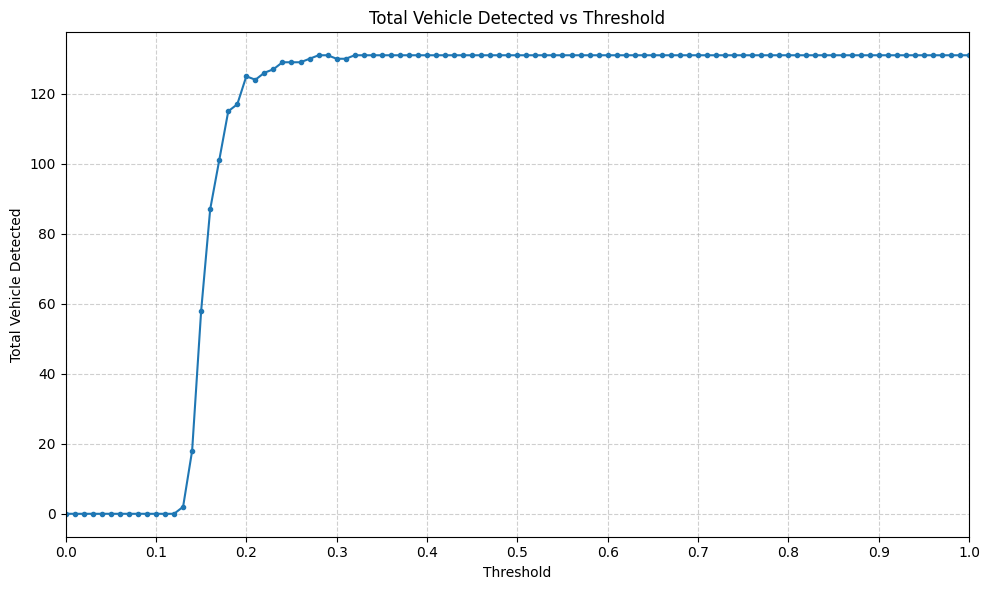

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(df['threshold'], df['total_vehicle_detected'], marker='o', linestyle='-', markersize=3, color='#1f77b4')

# Lock X-axis from 0 to 1 with 0.1 steps
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))

plt.xlabel('Threshold')
plt.ylabel('Total Vehicle Detected')
plt.title('Total Vehicle Detected vs Threshold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

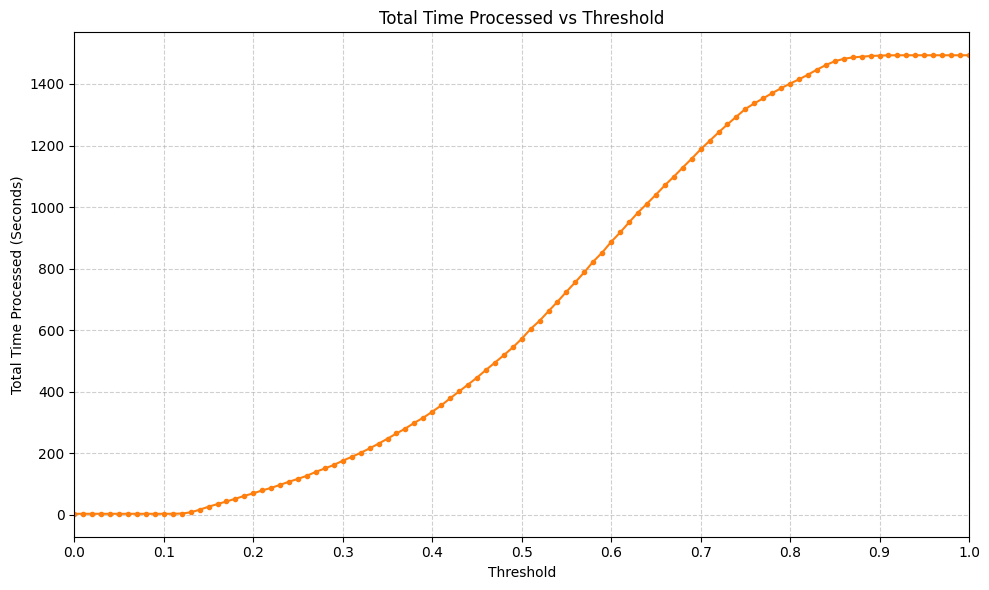

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(df['threshold'], df['total_time_processed'], marker='o', linestyle='-', markersize=3, color='#ff7f0e')

# Lock X-axis from 0 to 1 with 0.1 steps
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))

plt.xlabel('Threshold')
plt.ylabel('Total Time Processed (Seconds)')
plt.title('Total Time Processed vs Threshold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

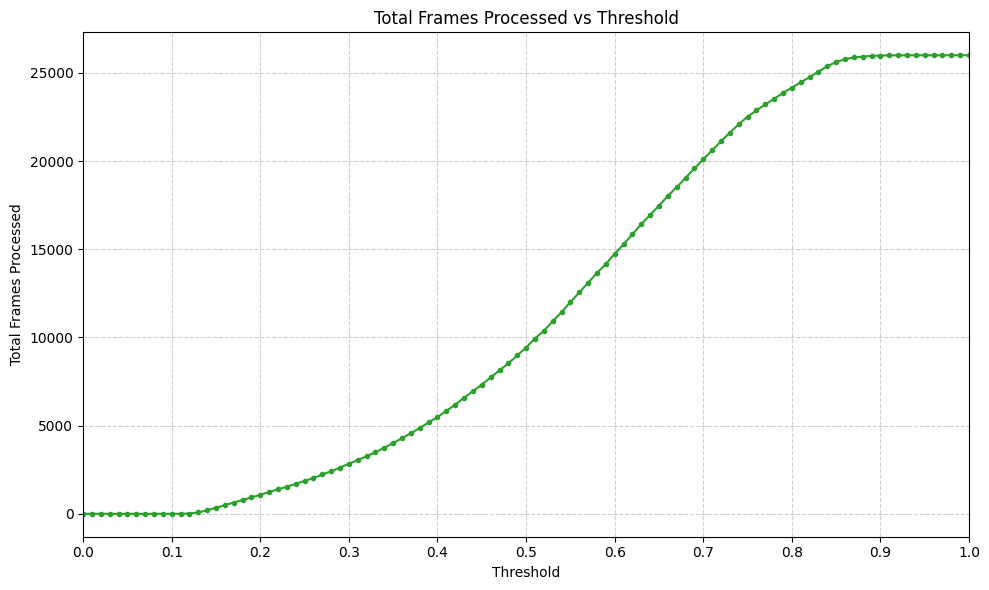

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(df['threshold'], df['total_frames_processed'], marker='o', linestyle='-', markersize=3, color='#2ca02c')

# Lock X-axis from 0 to 1 with 0.1 steps
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))

plt.xlabel('Threshold')
plt.ylabel('Total Frames Processed')
plt.title('Total Frames Processed vs Threshold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

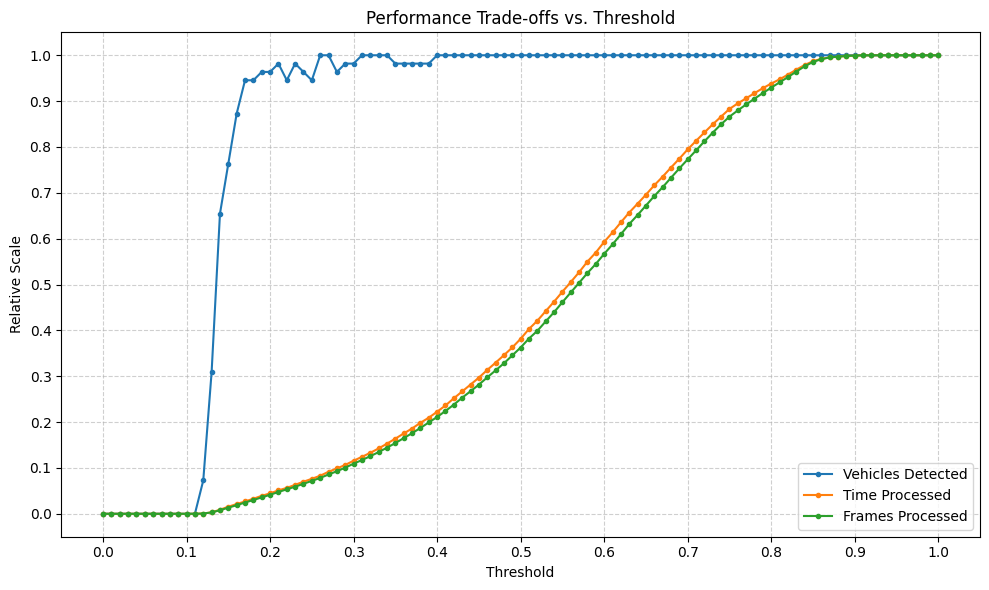

In [24]:
# Sort by threshold (important for smooth plotting)
df = df.sort_values(by="threshold")

# --- Normalize function (0 to 1 scale) ---
# [OPT] Defined ONCE here; the next cell reuses it instead of redefining it.
#       Added zero-range guard to avoid division by zero when all values equal.
def normalize(series: pd.Series) -> pd.Series:
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn) if mx != mn else series * 0.0

# Normalize metrics
df["vehicles_norm"] = normalize(df["total_vehicle_detected"])
df["time_norm"]     = normalize(df["total_time_processed"])
df["frames_norm"]   = normalize(df["total_frames_processed"])

# --- Plot ---
plt.figure(figsize=(10, 6))

plt.plot(df["threshold"], df["vehicles_norm"],
         label="Vehicles Detected", marker='o', markersize=3, linewidth=1.5)

plt.plot(df["threshold"], df["time_norm"],
         label="Time Processed", marker='o', markersize=3, linewidth=1.5)

plt.plot(df["threshold"], df["frames_norm"],
         label="Frames Processed", marker='o', markersize=3, linewidth=1.5)

# Labels and title
plt.title("Performance Trade-offs vs. Threshold")
plt.xlabel("Threshold")
plt.ylabel("Relative Scale")
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(np.arange(0, 1.1, 0.1))

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Tight layout for clean spacing
plt.tight_layout()

# Show plot
plt.show()


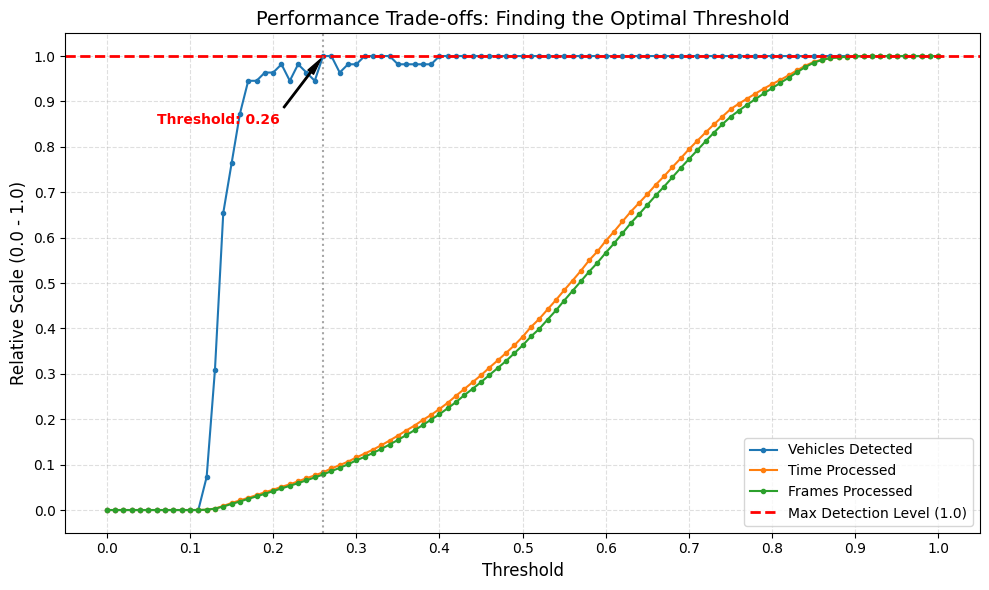

In [25]:
df = df.sort_values(by="threshold")

# [OPT] normalize() is already defined in the cell above — no redefinition needed.
df["vehicles_norm"] = normalize(df["total_vehicle_detected"])
df["time_norm"]     = normalize(df["total_time_processed"])
df["frames_norm"]   = normalize(df["total_frames_processed"])

# --- Optimization Logic ---
# Find the lowest threshold where normalized vehicles detected is 1.0 (or max)
max_vehicles       = df["vehicles_norm"].max()
best_threshold_row = df[df["vehicles_norm"] == max_vehicles].iloc[0]
best_threshold     = best_threshold_row["threshold"]
optimal_y_value    = best_threshold_row["vehicles_norm"]

# --- Plot ---
plt.figure(figsize=(10, 6))

plt.plot(df["threshold"], df["vehicles_norm"],
         label="Vehicles Detected", marker='o', markersize=3, linewidth=1.5, color='#1f77b4')
plt.plot(df["threshold"], df["time_norm"],
         label="Time Processed", marker='o', markersize=3, linewidth=1.5, color='#ff7f0e')
plt.plot(df["threshold"], df["frames_norm"],
         label="Frames Processed", marker='o', markersize=3, linewidth=1.5, color='#2ca02c')

# Add Horizontal Red Dashed Line
plt.axhline(y=optimal_y_value, color='r', linestyle='--', linewidth=2,
            label=f"Max Detection Level ({optimal_y_value})")

# Add Vertical indicator for where this happens
plt.axvline(x=best_threshold, color='gray', linestyle=':', alpha=0.7)

# Annotate the optimal point
plt.annotate(f'Threshold: {best_threshold}',
             xy=(best_threshold, optimal_y_value),
             xytext=(best_threshold - 0.2, optimal_y_value - 0.15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold', color='red')

# Labels and formatting
plt.title("Performance Trade-offs: Finding the Optimal Threshold", fontsize=14)
plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Relative Scale (0.0 - 1.0)", fontsize=12)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()
